# Pandas

The `numpy` module is excellent for numerical computations, but to handle missing data or arrays with mixed types takes more work. The `pandas` module is currently the most widely used tool for data manipulation, providing high-performance, easy-to-use data structures and advanced data analysis tools.

In particular `pandas` features:

* A fast and efficient "DataFrame" object for data manipulation with integrated indexing;
* Tools for reading and writing data between in-memory data structures and different formats (CSV, Excel, SQL, HDF5);
* Intelligent data alignment and integrated handling of missing data;
* Intelligent label-based slicing, fancy indexing, and subsetting of large data sets;
* Aggregating or transforming data with a powerful "group-by" engine; 
* High performance merging and joining of data sets;
* Hierarchical axis indexing provides an intuitive way of working with high-dimensional data in a lower-dimensional data structure;
* Time series-functionalities;
* Highly optimized for performance, with critical code paths written in Cython or C.


In [2]:
import pandas as pd
import numpy as np

## Series

Series are completely equivalent to 1D array but with axis labels and the possibility to store heterogeneous elements. Of paramount importance are the time-series, used to define time evolutions of a phenomenon. 


In [2]:
from string import ascii_lowercase as letters

# Creating a series, accessing indexes, values and values by their index 
xs = pd.Series(np.arange(10)*0.5, index=tuple(letters[:10]))
print ("xs:", xs,'\n')
print ("xs indexes:",xs.index,'\n')
# Values of the Series are actually a numpy array
print ("xs values:", xs.values, type(xs.values),'\n')
print (xs['f'], xs.f, xs.h, '\n')
print (xs[['d', 'f', 'h']], '\n')
print (type(xs[['d', 'f', 'h']]), '\n')

xs: a    0.0
b    0.5
c    1.0
d    1.5
e    2.0
f    2.5
g    3.0
h    3.5
i    4.0
j    4.5
dtype: float64 

xs indexes: Index(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'], dtype='object') 

xs values: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5] <class 'numpy.ndarray'> 

2.5 2.5 3.5 

d    1.5
f    2.5
h    3.5
dtype: float64 

<class 'pandas.core.series.Series'> 



In [3]:
# Extracting elements and operations: same as numpy array
print (xs[:3],'\n')
print (xs[7:], '\n')
print (xs[::3], '\n')
print (xs[xs>3], '\n')
print (np.exp(xs), '\n')
print (np.mean(xs), np.std(xs), '\n')

a    0.0
b    0.5
c    1.0
dtype: float64 

h    3.5
i    4.0
j    4.5
dtype: float64 

a    0.0
d    1.5
g    3.0
j    4.5
dtype: float64 

h    3.5
i    4.0
j    4.5
dtype: float64 

a     1.000000
b     1.648721
c     2.718282
d     4.481689
e     7.389056
f    12.182494
g    20.085537
h    33.115452
i    54.598150
j    90.017131
dtype: float64 

2.25 1.4361406616345072 



In [4]:
# Series can be created from python dictionary too.
# Not that the elements can be whatever!
d = {'b' : 1, 'a' : 'cat', 'c' : [2,3]}
pd.Series(d)



b         1
a       cat
c    [2, 3]
dtype: object

A key difference between Series and ndarray is that operations between Series automatically align the data based on label. Thus, you can write computations without considering whether the Series involved have the same labels.

In [5]:
s = pd.Series(np.random.randn(5), index=tuple(letters[:5]))
print(s)
print(s[1:])
print(s[:-1 ])
s = s[1:] + s[:-1] #it will always sum a with a, b with b, etc...
print(s)

a    1.022259
b   -0.427093
c    0.584270
d    1.087243
e   -1.020214
dtype: float64
b   -0.427093
c    0.584270
d    1.087243
e   -1.020214
dtype: float64
a    1.022259
b   -0.427093
c    0.584270
d    1.087243
dtype: float64
a         NaN
b   -0.854186
c    1.168540
d    2.174485
e         NaN
dtype: float64


### Time series

Time series are very often used to profile the behaviour of a quantity as a function of time. Pandas has a special index for that, `DatetimeIndex`, that can be created e.g. with the function `pd.data_range()`

In [6]:
# to define a date, the datetime module is very useful
import datetime as dt
date = dt.date.today()
print(date)

date = dt.datetime(2025,11,26,10,45,10,15)
print (date)

# otherwise, several notations are interpreted too
date = 'Nov 26 2025'
# or alternatively
#date = '26/11/2025 10:45:00'
print (date)

days = pd.date_range(date, periods=7, freq='D')
print (days)

seconds = pd.date_range(date, periods=3600, freq='s')
print (seconds)


2026-01-30
2025-11-26 10:45:10.000015
Nov 26 2025
DatetimeIndex(['2025-11-26', '2025-11-27', '2025-11-28', '2025-11-29',
               '2025-11-30', '2025-12-01', '2025-12-02'],
              dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2025-11-26 00:00:00', '2025-11-26 00:00:01',
               '2025-11-26 00:00:02', '2025-11-26 00:00:03',
               '2025-11-26 00:00:04', '2025-11-26 00:00:05',
               '2025-11-26 00:00:06', '2025-11-26 00:00:07',
               '2025-11-26 00:00:08', '2025-11-26 00:00:09',
               ...
               '2025-11-26 00:59:50', '2025-11-26 00:59:51',
               '2025-11-26 00:59:52', '2025-11-26 00:59:53',
               '2025-11-26 00:59:54', '2025-11-26 00:59:55',
               '2025-11-26 00:59:56', '2025-11-26 00:59:57',
               '2025-11-26 00:59:58', '2025-11-26 00:59:59'],
              dtype='datetime64[ns]', length=3600, freq='S')


To learn more about the frequency strings, please see this [link](http://pandas.pydata.org/pandas-docs/stable/timeseries.html#offset-aliases)


Timestamped data is the most basic type of time series data that associates values with points in time. For pandas objects it means using the points in time.

functions like `pd.to_datetime` can be used, for instance, when reading information as string from a dataset.

Timestamp is the pandas equivalent of python’s Datetime and is interchangeable with it in most cases. 

In [7]:
tstamp = pd.Timestamp(dt.datetime(2020, 11, 9))

# internally it counts the nanoseconds from January 1st 19
#tstamp = pd.Timestamp(dt.datetime(1970, 1, 1, 0, 0, 0, 1))
print(tstamp.value)

# when creating a timestamp the format can be explicitly passed
ts = pd.to_datetime('2010/11/12', format='%Y/%m/%d')
print (type(ts))
print (ts.value)
ts = pd.to_datetime('12-11-2010 00:01', format='%d-%m-%Y %H:%M')
print (ts)
print (ts.value)



1604880000000000000
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
1289520000000000000
2010-11-12 00:01:00
1289520060000000000


A standard series can be created and (range of) elements can be used as indexes

In [8]:
tseries = pd.Series(np.random.normal(10, 1, len(days)), index=days)
# Extracting elements
print (tseries[0:4], '\n')
print (tseries['2025-11-26':'2025-12-02'], '\n') # Note - includes end time


2025-11-26    11.167072
2025-11-27     9.700610
2025-11-28    11.475442
2025-11-29    10.204169
Freq: D, dtype: float64 

2025-11-26    11.167072
2025-11-27     9.700610
2025-11-28    11.475442
2025-11-29    10.204169
2025-11-30     9.668164
2025-12-01    10.306565
2025-12-02     9.796747
Freq: D, dtype: float64 



`pd.to_datetime` can also be used to create a `DatetimeIndex`:

In [9]:
pd.to_datetime([1, 2, 3, 4], unit='D', origin=pd.Timestamp('1980-02-03'))

DatetimeIndex(['1980-02-04', '1980-02-05', '1980-02-06', '1980-02-07'], dtype='datetime64[ns]', freq=None)

## DataFrame

A pandas DataFrame is like a simple tabular spreadsheet. For future reference (or for people already familiar with R), a pandas DataFrame is very similar to the R DataFrame.

Each column in a DataFrame is a Series object.

The element can be whatever, missing data are dealt with too (as NaN)

### DataFrame creation

A DataFrame can be created implicitly, with, e.g., a DatatimeIndex object as index:

In [12]:
entries=10
dates=pd.date_range('11/26/2025 10:45:00',freq='h', periods=entries)
df = pd.DataFrame(np.random.randn(entries,4), index=dates, columns=['A','B','C','D'])
df
print (df)
print ( df['A'].max(axis=0))
print(len(df.index))
df.index[0]

                            A         B         C         D
2025-11-26 10:45:00 -1.315061  0.298235  0.057245  0.012607
2025-11-26 11:45:00 -2.638480 -0.033825  0.782006  0.487623
2025-11-26 12:45:00  1.472402 -1.518999 -0.707839 -1.908560
2025-11-26 13:45:00 -0.937980  0.381955 -0.832243 -0.131939
2025-11-26 14:45:00  0.482385  1.952189  0.155327  1.778289
2025-11-26 15:45:00 -0.361269 -0.982164  1.025173  1.276015
2025-11-26 16:45:00 -0.878809 -0.843278  0.281359 -0.638401
2025-11-26 17:45:00  0.102006  0.849063 -0.102428 -0.092189
2025-11-26 18:45:00 -1.227857 -0.286249 -0.252970  1.316986
2025-11-26 19:45:00  0.989866  1.095408  1.493474 -0.073739
1.4724019649870113
10


Timestamp('2025-11-26 10:45:00')

or by means of a dictionary:


In [11]:
df2 = pd.DataFrame(
    { 'A' : 1.,
      'B' : pd.Timestamp('20130102'),
      'C' : pd.Series(1,index=range(4),dtype='float32'),
      'D' : np.arange(7,11),
      'E' : pd.Categorical(["test","train","test","train"]),
    }
    )
df2

# check what happens if D and E had different lenghts 

,A,B,C,D,E
0,1.0,2013-01-02,1.0,7,test
1,1.0,2013-01-02,1.0,8,train
2,1.0,2013-01-02,1.0,9,test
3,1.0,2013-01-02,1.0,10,train


### Viewing Data

In [12]:
df.head(2)  #df = dataframe

,A,B,C,D
2025-11-26 10:45:00,0.518067,-0.429261,-0.635243,0.418862
2025-11-26 11:45:00,-1.089622,1.052621,-1.935317,-1.410685


In [13]:
df.tail(4)

,A,B,C,D
2025-11-26 16:45:00,2.772206,0.334959,-0.446249,-0.354307
2025-11-26 17:45:00,-0.624228,-0.004846,-0.585180,-0.830578
2025-11-26 18:45:00,-1.110583,-1.233583,-0.625249,-0.434482
2025-11-26 19:45:00,-0.757397,1.340505,-0.484127,0.863585


In [14]:
df.index

DatetimeIndex(['2025-11-26 10:45:00', '2025-11-26 11:45:00',
               '2025-11-26 12:45:00', '2025-11-26 13:45:00',
               '2025-11-26 14:45:00', '2025-11-26 15:45:00',
               '2025-11-26 16:45:00', '2025-11-26 17:45:00',
               '2025-11-26 18:45:00', '2025-11-26 19:45:00'],
              dtype='datetime64[ns]', freq='H')

In [15]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

In [16]:
df.values

array([[ 0.5180671 , -0.42926085, -0.63524261,  0.41886203],
       [-1.08962173,  1.05262093, -1.93531664, -1.41068499],
       [-0.0250153 , -0.79052429,  1.05435162, -1.03705374],
       [ 0.82873255,  0.200452  , -1.32636691,  0.24737751],
       [ 0.68210766, -1.0987708 , -0.63940591, -0.28893191],
       [ 0.73215622,  0.92049122, -0.40742834, -0.22365368],
       [ 2.77220637,  0.33495935, -0.4462488 , -0.35430722],
       [-0.62422761, -0.00484577, -0.5851803 , -0.8305782 ],
       [-1.11058319, -1.23358291, -0.62524866, -0.43448157],
       [-0.75739669,  1.34050461, -0.48412735,  0.86358465]])

In [17]:
df.describe()

,A,B,C,D
count,10.000000,10.000000,10.000000,10.000000
mean,0.192643,0.029204,-0.603021,-0.304987
std,1.185802,0.908867,0.754635,0.687623
min,-1.110583,-1.233583,-1.935317,-1.410685
25%,-0.724104,-0.700208,-0.638365,-0.731554
50%,0.246526,0.097803,-0.605214,-0.321620
75%,0.719644,0.774108,-0.455718,0.129620
max,2.772206,1.340505,1.054352,0.863585


In [18]:
df.T

,2025-11-26 10:45:00,2025-11-26 11:45:00,2025-11-26 12:45:00,2025-11-26 13:45:00,2025-11-26 14:45:00,2025-11-26 15:45:00,2025-11-26 16:45:00,2025-11-26 17:45:00,2025-11-26 18:45:00,2025-11-26 19:45:00
A,0.518067,-1.089622,-0.025015,0.828733,0.682108,0.732156,2.772206,-0.624228,-1.110583,-0.757397
B,-0.429261,1.052621,-0.790524,0.200452,-1.098771,0.920491,0.334959,-0.004846,-1.233583,1.340505
C,-0.635243,-1.935317,1.054352,-1.326367,-0.639406,-0.407428,-0.446249,-0.585180,-0.625249,-0.484127
D,0.418862,-1.410685,-1.037054,0.247378,-0.288932,-0.223654,-0.354307,-0.830578,-0.434482,0.863585


In [19]:
df.sort_index(axis=0,ascending=False)

,A,B,C,D
2025-11-26 19:45:00,-0.757397,1.340505,-0.484127,0.863585
2025-11-26 18:45:00,-1.110583,-1.233583,-0.625249,-0.434482
2025-11-26 17:45:00,-0.624228,-0.004846,-0.585180,-0.830578
2025-11-26 16:45:00,2.772206,0.334959,-0.446249,-0.354307
2025-11-26 15:45:00,0.732156,0.920491,-0.407428,-0.223654
2025-11-26 14:45:00,0.682108,-1.098771,-0.639406,-0.288932
2025-11-26 13:45:00,0.828733,0.200452,-1.326367,0.247378
2025-11-26 12:45:00,-0.025015,-0.790524,1.054352,-1.037054
2025-11-26 11:45:00,-1.089622,1.052621,-1.935317,-1.410685
2025-11-26 10:45:00,0.518067,-0.429261,-0.635243,0.418862


In [20]:
df.sort_values(by="C")

,A,B,C,D
2025-11-26 11:45:00,-1.089622,1.052621,-1.935317,-1.410685
2025-11-26 13:45:00,0.828733,0.200452,-1.326367,0.247378
2025-11-26 14:45:00,0.682108,-1.098771,-0.639406,-0.288932
2025-11-26 10:45:00,0.518067,-0.429261,-0.635243,0.418862
2025-11-26 18:45:00,-1.110583,-1.233583,-0.625249,-0.434482
2025-11-26 17:45:00,-0.624228,-0.004846,-0.585180,-0.830578
2025-11-26 19:45:00,-0.757397,1.340505,-0.484127,0.863585
2025-11-26 16:45:00,2.772206,0.334959,-0.446249,-0.354307
2025-11-26 15:45:00,0.732156,0.920491,-0.407428,-0.223654
2025-11-26 12:45:00,-0.025015,-0.790524,1.054352,-1.037054


## Selection

### Getting slices

The following show how to get part of the DataFrame (i.e. not just the elements)

In [21]:
## standard and safe
print (df['A'],'\n')

## equivalent but dangerous (imagine blank spaces in the name of the column..)
print (df.A)

2025-11-26 10:45:00    0.518067
2025-11-26 11:45:00   -1.089622
2025-11-26 12:45:00   -0.025015
2025-11-26 13:45:00    0.828733
2025-11-26 14:45:00    0.682108
2025-11-26 15:45:00    0.732156
2025-11-26 16:45:00    2.772206
2025-11-26 17:45:00   -0.624228
2025-11-26 18:45:00   -1.110583
2025-11-26 19:45:00   -0.757397
Freq: H, Name: A, dtype: float64 

2025-11-26 10:45:00    0.518067
2025-11-26 11:45:00   -1.089622
2025-11-26 12:45:00   -0.025015
2025-11-26 13:45:00    0.828733
2025-11-26 14:45:00    0.682108
2025-11-26 15:45:00    0.732156
2025-11-26 16:45:00    2.772206
2025-11-26 17:45:00   -0.624228
2025-11-26 18:45:00   -1.110583
2025-11-26 19:45:00   -0.757397
Freq: H, Name: A, dtype: float64


In [22]:
# selecting rows by counting
print (df[0:3])


# or by index
print (df["2025-11-26 10:45:00":"2025-11-26 12:45:00"])

                            A         B         C         D
2025-11-26 10:45:00  0.518067 -0.429261 -0.635243  0.418862
2025-11-26 11:45:00 -1.089622  1.052621 -1.935317 -1.410685
2025-11-26 12:45:00 -0.025015 -0.790524  1.054352 -1.037054
                            A         B         C         D
2025-11-26 10:45:00  0.518067 -0.429261 -0.635243  0.418862
2025-11-26 11:45:00 -1.089622  1.052621 -1.935317 -1.410685
2025-11-26 12:45:00 -0.025015 -0.790524  1.054352 -1.037054


### Selection by label

In [23]:
# getting a cross section (part of the DataFrame) using a label
df.loc[dates[0]]

A    0.518067
B   -0.429261
C   -0.635243
D    0.418862
Name: 2025-11-26 10:45:00, dtype: float64

In [24]:
# selecting on a multi-axis by label:
df.loc[:"2025-11-26 12:45:00",['A','B']]
#a=df.loc[:,['A','B']]

,A,B
2025-11-26 10:45:00,0.518067,-0.429261
2025-11-26 11:45:00,-1.089622,1.052621
2025-11-26 12:45:00,-0.025015,-0.790524


In [25]:
# showing label slicing, both endpoints are included:
df.loc['2025-11-26 14:45:00':'2025-11-26 16:45:00',['A','B']]

,A,B
2025-11-26 14:45:00,0.682108,-1.098771
2025-11-26 15:45:00,0.732156,0.920491
2025-11-26 16:45:00,2.772206,0.334959


In [26]:
# getting an individual element
print (df.loc[dates[1],'A'])

# equivalently
print (df.at[dates[1],'A'])

-1.089621725556241
-1.089621725556241


### Selecting by position

In [27]:
# select via the position of the passed integers:
print (df.iloc[3],'\n')

# notation similar to numpy/python
print (df.iloc[3:5,0:2])

A    0.828733
B    0.200452
C   -1.326367
D    0.247378
Name: 2025-11-26 13:45:00, dtype: float64 

                            A         B
2025-11-26 13:45:00  0.828733  0.200452
2025-11-26 14:45:00  0.682108 -1.098771


In [28]:
# selecting raws 1,2 and 4 for columns 0 and 2
df.iloc[[1,2,4],[0,2]]

,A,C
2025-11-26 11:45:00,-1.089622,-1.935317
2025-11-26 12:45:00,-0.025015,1.054352
2025-11-26 14:45:00,0.682108,-0.639406


In [29]:
# slicing rows explicitly
print (df.iloc[1:3,:],'\n')

# slicing columns explicitly
print (df.iloc[:,1:3])

# selecting an individual element by position
print(df.iloc[1,1])

                            A         B         C         D
2025-11-26 11:45:00 -1.089622  1.052621 -1.935317 -1.410685
2025-11-26 12:45:00 -0.025015 -0.790524  1.054352 -1.037054 

                            B         C
2025-11-26 10:45:00 -0.429261 -0.635243
2025-11-26 11:45:00  1.052621 -1.935317
2025-11-26 12:45:00 -0.790524  1.054352
2025-11-26 13:45:00  0.200452 -1.326367
2025-11-26 14:45:00 -1.098771 -0.639406
2025-11-26 15:45:00  0.920491 -0.407428
2025-11-26 16:45:00  0.334959 -0.446249
2025-11-26 17:45:00 -0.004846 -0.585180
2025-11-26 18:45:00 -1.233583 -0.625249
2025-11-26 19:45:00  1.340505 -0.484127
1.0526209298949787


### Boolean index

Very powerful way of filtering out data with certain features. Notation is very similar to numpy arrays.

In [30]:
# Filter by a boolean condition on the values of a single column
df[df['B'] > 0]

,A,B,C,D
2025-11-26 11:45:00,-1.089622,1.052621,-1.935317,-1.410685
2025-11-26 13:45:00,0.828733,0.200452,-1.326367,0.247378
2025-11-26 15:45:00,0.732156,0.920491,-0.407428,-0.223654
2025-11-26 16:45:00,2.772206,0.334959,-0.446249,-0.354307
2025-11-26 19:45:00,-0.757397,1.340505,-0.484127,0.863585


In [31]:
# Selecting on the basis of boolean conditions applied to the whole DataFrame
df[df>0]

# a DataFrame with the same shape is returned, with NaN's where condition is not met

,A,B,C,D
2025-11-26 10:45:00,0.518067,NaN,NaN,0.418862
2025-11-26 11:45:00,NaN,1.052621,NaN,NaN
2025-11-26 12:45:00,NaN,NaN,1.054352,NaN
2025-11-26 13:45:00,0.828733,0.200452,NaN,0.247378
2025-11-26 14:45:00,0.682108,NaN,NaN,NaN
2025-11-26 15:45:00,0.732156,0.920491,NaN,NaN
2025-11-26 16:45:00,2.772206,0.334959,NaN,NaN
2025-11-26 17:45:00,NaN,NaN,NaN,NaN
2025-11-26 18:45:00,NaN,NaN,NaN,NaN
2025-11-26 19:45:00,NaN,1.340505,NaN,0.863585


### Setting

Combination of selection and setting of values

In [33]:
# setting values by label (same as by position)
df.at[dates[0],'A'] = 0

# setting and assigning a numpy array
df.loc[:,'D'] = np.array([5] * len(df))

# defining a brend new column
df['E'] = np.arange(len(df))*0.5

# defining a brend new column by means of a pd.Series: indexes must be the same!
#df['E prime'] = pd.Series(np.arange(len(df))*2, index=df.index)

df

,A,B,C,D,E
2025-11-26 10:45:00,0.000000,-0.429261,-0.635243,5.0,0.0
2025-11-26 11:45:00,-1.089622,1.052621,-1.935317,5.0,0.5
2025-11-26 12:45:00,-0.025015,-0.790524,1.054352,5.0,1.0
2025-11-26 13:45:00,0.828733,0.200452,-1.326367,5.0,1.5
2025-11-26 14:45:00,0.682108,-1.098771,-0.639406,5.0,2.0
2025-11-26 15:45:00,0.732156,0.920491,-0.407428,5.0,2.5
2025-11-26 16:45:00,2.772206,0.334959,-0.446249,5.0,3.0
2025-11-26 17:45:00,-0.624228,-0.004846,-0.585180,5.0,3.5
2025-11-26 18:45:00,-1.110583,-1.233583,-0.625249,5.0,4.0
2025-11-26 19:45:00,-0.757397,1.340505,-0.484127,5.0,4.5


In [ ]:
def dcos(theta):
    theta = theta*(np.pi/180)
    return np.cos(theta)
 
df['cosine'] = pd.Series(df["E"].apply(dcos), index=df.index)
df

In [ ]:
# another example of global setting
df2=df.copy()

df2[df2>0] = -df2
df2

### Are you dealing with a Copy or a View?

In general is hard to tell..

In [37]:
dfd = pd.DataFrame({'a': [1, 2, 3], 'b': [4, 5, 6]})

# This is likely a view
subset = dfd.loc[0:1, 'a']  
subset[0] = 100  # May affect `df`

print (dfd)

# This is a copy
subset = dfd.loc[[0, 1], 'a']  
subset[0] = 200  # Does NOT affect `df`

print (dfd)



     a  b
0  100  4
1    2  5
2    3  6
     a  b
0  100  4
1    2  5
2    3  6


The behaviour depend on the version of Pandas and on the version of Numpy that given version of Pandas depends upon. Since Pandas 1.5 "Copy-on-Write" (CoW) is (optionally) available and as of Pandas 3.0 will be the default. 

With CoW chained assignemt will never work; in the following example, the view `dfd["a"]` and `df` itself are modified in one step. This will lead to a `ChainedAssignemntError`  

In [38]:
dfd["a"][dfd["b"] > 5] = 100
dfd

,a,b
0,100,4
1,2,5
2,100,6


With copy on write this can be done by using `loc`

In [39]:
dfd.loc[dfd["b"] > 5, "a"] = 200
dfd

,a,b
0,100,4
1,2,5
2,200,6


### Dropping

N.B.: dropping doesn't act permanently on the DataFrame, i.e. to get that do :
```python
df = df.drop(....)
```

In [43]:
# Dropping by column
df.drop(['E prime'], axis=1)

#which is equivalent to
new_df=df.drop(columns=['E prime'])
new_df

KeyError: "['E prime'] not found in axis"

In [41]:
# Dropping by raws
# safe and always working
df.drop(df.index[[1,2,3,4]])

,A,B,C,D
2025-11-26 10:45:00,-1.515999,0.885592,1.275391,-0.164114
2025-11-26 15:45:00,1.266955,-0.437335,-1.043579,-1.025844
2025-11-26 16:45:00,0.091859,0.012899,0.493024,-0.654967
2025-11-26 17:45:00,-1.330268,1.923082,0.160996,0.879760
2025-11-26 18:45:00,-0.003482,0.296670,0.296267,1.419474
2025-11-26 19:45:00,0.871622,-0.183285,-0.055570,-1.481343


In [42]:
df

,A,B,C,D
2025-11-26 10:45:00,-1.515999,0.885592,1.275391,-0.164114
2025-11-26 11:45:00,0.781375,1.190080,0.337706,-2.750746
2025-11-26 12:45:00,0.640245,-1.242148,-1.207228,-0.561758
2025-11-26 13:45:00,1.248367,-1.225608,0.772297,0.018072
2025-11-26 14:45:00,-0.695102,0.031656,1.126940,0.318884
2025-11-26 15:45:00,1.266955,-0.437335,-1.043579,-1.025844
2025-11-26 16:45:00,0.091859,0.012899,0.493024,-0.654967
2025-11-26 17:45:00,-1.330268,1.923082,0.160996,0.879760
2025-11-26 18:45:00,-0.003482,0.296670,0.296267,1.419474
2025-11-26 19:45:00,0.871622,-0.183285,-0.055570,-1.481343


In [98]:
# something like df.drop('index_name') 
# would work but the type of index must be specificed, 
# in particular with DatetimeIndex
df.drop(pd.to_datetime("2025-11-26 18:45:00"))

,A,B,C,D,E,E prime,cosine
2025-11-26 10:45:00,0.000000,-0.739688,0.374828,5.0,0.0,0,1.000000
2025-11-26 11:45:00,1.214175,-0.528877,1.538602,5.0,0.5,2,0.999962
2025-11-26 12:45:00,0.240860,-0.905741,0.309310,5.0,1.0,4,0.999848
2025-11-26 13:45:00,1.502915,-0.678270,1.625756,5.0,1.5,6,0.999657
2025-11-26 14:45:00,-1.389510,-0.703572,0.557716,5.0,2.0,8,0.999391
2025-11-26 15:45:00,-1.391653,-0.636169,1.270925,5.0,2.5,10,0.999048
2025-11-26 16:45:00,-0.559034,0.277103,-0.683708,5.0,3.0,12,0.998630
2025-11-26 17:45:00,0.019827,1.122219,1.051807,5.0,3.5,14,0.998135
2025-11-26 19:45:00,0.245885,-1.408324,-1.390113,5.0,4.5,18,0.996917


## Missing data

pandas primarily uses the value np.nan to represent missing data. It is by default not included in computations.

In [99]:
df_wNan = df[df>-0.5]
df_wNan

,A,B,C,D,E,E prime,cosine
2025-11-26 10:45:00,0.000000,NaN,0.374828,5.0,0.0,0,1.000000
2025-11-26 11:45:00,1.214175,NaN,1.538602,5.0,0.5,2,0.999962
2025-11-26 12:45:00,0.240860,NaN,0.309310,5.0,1.0,4,0.999848
2025-11-26 13:45:00,1.502915,NaN,1.625756,5.0,1.5,6,0.999657
2025-11-26 14:45:00,NaN,NaN,0.557716,5.0,2.0,8,0.999391
2025-11-26 15:45:00,NaN,NaN,1.270925,5.0,2.5,10,0.999048
2025-11-26 16:45:00,NaN,0.277103,NaN,5.0,3.0,12,0.998630
2025-11-26 17:45:00,0.019827,1.122219,1.051807,5.0,3.5,14,0.998135
2025-11-26 18:45:00,1.324253,0.517560,0.266981,5.0,4.0,16,0.997564
2025-11-26 19:45:00,0.245885,NaN,NaN,5.0,4.5,18,0.996917


In [100]:
# dropping raws with at least a Nan
df_wNan.dropna(how='any')

,A,B,C,D,E,E prime,cosine
2025-11-26 17:45:00,0.019827,1.122219,1.051807,5.0,3.5,14,0.998135
2025-11-26 18:45:00,1.324253,0.517560,0.266981,5.0,4.0,16,0.997564


In [101]:
# getting a mask
df_wNan.isna()
#df_wNan.notna()

,A,B,C,D,E,E prime,cosine
2025-11-26 10:45:00,False,True,False,False,False,False,False
2025-11-26 11:45:00,False,True,False,False,False,False,False
2025-11-26 12:45:00,False,True,False,False,False,False,False
2025-11-26 13:45:00,False,True,False,False,False,False,False
2025-11-26 14:45:00,True,True,False,False,False,False,False
2025-11-26 15:45:00,True,True,False,False,False,False,False
2025-11-26 16:45:00,True,False,True,False,False,False,False
2025-11-26 17:45:00,False,False,False,False,False,False,False
2025-11-26 18:45:00,False,False,False,False,False,False,False
2025-11-26 19:45:00,False,True,True,False,False,False,False


In [102]:
# filling missing data
df_wNan.fillna(value=0)

,A,B,C,D,E,E prime,cosine
2025-11-26 10:45:00,0.000000,0.000000,0.374828,5.0,0.0,0,1.000000
2025-11-26 11:45:00,1.214175,0.000000,1.538602,5.0,0.5,2,0.999962
2025-11-26 12:45:00,0.240860,0.000000,0.309310,5.0,1.0,4,0.999848
2025-11-26 13:45:00,1.502915,0.000000,1.625756,5.0,1.5,6,0.999657
2025-11-26 14:45:00,0.000000,0.000000,0.557716,5.0,2.0,8,0.999391
2025-11-26 15:45:00,0.000000,0.000000,1.270925,5.0,2.5,10,0.999048
2025-11-26 16:45:00,0.000000,0.277103,0.000000,5.0,3.0,12,0.998630
2025-11-26 17:45:00,0.019827,1.122219,1.051807,5.0,3.5,14,0.998135
2025-11-26 18:45:00,1.324253,0.517560,0.266981,5.0,4.0,16,0.997564
2025-11-26 19:45:00,0.245885,0.000000,0.000000,5.0,4.5,18,0.996917


Fill gaps forward or backward by propagating non-NA values forward or backward:

In [103]:
df_wNan.fillna(method='pad')

,A,B,C,D,E,E prime,cosine
2025-11-26 10:45:00,0.000000,NaN,0.374828,5.0,0.0,0,1.000000
2025-11-26 11:45:00,1.214175,NaN,1.538602,5.0,0.5,2,0.999962
2025-11-26 12:45:00,0.240860,NaN,0.309310,5.0,1.0,4,0.999848
2025-11-26 13:45:00,1.502915,NaN,1.625756,5.0,1.5,6,0.999657
2025-11-26 14:45:00,1.502915,NaN,0.557716,5.0,2.0,8,0.999391
2025-11-26 15:45:00,1.502915,NaN,1.270925,5.0,2.5,10,0.999048
2025-11-26 16:45:00,1.502915,0.277103,1.270925,5.0,3.0,12,0.998630
2025-11-26 17:45:00,0.019827,1.122219,1.051807,5.0,3.5,14,0.998135
2025-11-26 18:45:00,1.324253,0.517560,0.266981,5.0,4.0,16,0.997564
2025-11-26 19:45:00,0.245885,0.517560,0.266981,5.0,4.5,18,0.996917


## Operations

Here comes the most relevant advantage of DataFrame. Operations on columns are extremly fast due to several intrinsic optimizations:

* They are implemented in C/Cython via NumPy.
* Pandas processes columns as contiguous memory arrays.
* Vectorized operations eliminate the need for slow Python loops.
* Efficient memory and cache utilization boost performance.


In [108]:
# Some statistics (mean() just as an example)
# raws
print (df.mean(axis=0),'\n')
# columns
print (df.mean(axis=1),'\n')
print ( df.min(axis=1))
print(df.sum(axis=0))


A          0.120772
B         -0.368376
C          0.492210
D          5.000000
E          2.250000
E prime    9.000000
cosine     0.998915
dtype: float64 

2025-11-26 10:45:00    0.805020
2025-11-26 11:45:00    1.531980
2025-11-26 12:45:00    1.520611
2025-11-26 13:45:00    2.278580
2025-11-26 14:45:00    2.066289
2025-11-26 15:45:00    2.534593
2025-11-26 16:45:00    2.861856
2025-11-26 17:45:00    3.670284
2025-11-26 18:45:00    4.015194
2025-11-26 19:45:00    3.706338
Freq: H, dtype: float64 

2025-11-26 10:45:00   -0.739688
2025-11-26 11:45:00   -0.528877
2025-11-26 12:45:00   -0.905741
2025-11-26 13:45:00   -0.678270
2025-11-26 14:45:00   -1.389510
2025-11-26 15:45:00   -1.391653
2025-11-26 16:45:00   -0.683708
2025-11-26 17:45:00    0.019827
2025-11-26 18:45:00    0.266981
2025-11-26 19:45:00   -1.408324
Freq: H, dtype: float64
A           1.207719
B          -3.683758
C           4.922102
D          50.000000
E          22.500000
E prime    90.000000
cosine      9.989152
dtype:

In [47]:
# global operations on columns comulative sum
df.apply(np.cumsum)

,A,B,C,D
2025-11-26 10:45:00,-1.515999,0.885592,1.275391,-0.164114
2025-11-26 11:45:00,-0.734624,2.075672,1.613097,-2.914860
2025-11-26 12:45:00,-0.094379,0.833524,0.405868,-3.476618
2025-11-26 13:45:00,1.153988,-0.392084,1.178166,-3.458546
2025-11-26 14:45:00,0.458886,-0.360428,2.305106,-3.139661
2025-11-26 15:45:00,1.725841,-0.797763,1.261527,-4.165506
2025-11-26 16:45:00,1.817700,-0.784863,1.754550,-4.820473
2025-11-26 17:45:00,0.487432,1.138219,1.915547,-3.940713
2025-11-26 18:45:00,0.483949,1.434889,2.211813,-2.521239
2025-11-26 19:45:00,1.355571,1.251603,2.156244,-4.002582


In [46]:
df

,A,B,C,D
2025-11-26 10:45:00,-1.515999,0.885592,1.275391,-0.164114
2025-11-26 11:45:00,0.781375,1.190080,0.337706,-2.750746
2025-11-26 12:45:00,0.640245,-1.242148,-1.207228,-0.561758
2025-11-26 13:45:00,1.248367,-1.225608,0.772297,0.018072
2025-11-26 14:45:00,-0.695102,0.031656,1.126940,0.318884
2025-11-26 15:45:00,1.266955,-0.437335,-1.043579,-1.025844
2025-11-26 16:45:00,0.091859,0.012899,0.493024,-0.654967
2025-11-26 17:45:00,-1.330268,1.923082,0.160996,0.879760
2025-11-26 18:45:00,-0.003482,0.296670,0.296267,1.419474
2025-11-26 19:45:00,0.871622,-0.183285,-0.055570,-1.481343


In [20]:
df.apply(lambda x: x.max() - x.min())

A    2.774625
B    3.243808
C    2.826444
D    4.033874
dtype: float64

In [52]:
# syntax is as usual similar to that of numpy arrays
df['A']+df['B']

KeyError: 'A'

Let's play it hard and load (in memory) a (relatively) large dataset

In [54]:
# WARNING! link in past notebook was wrong!, (if needed) get the right file from:
#!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

file_name="~/data/data_000637.txt"
data=pd.read_csv(file_name)
data.tail(10)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
1310710,1,1,36,3869211171,427,13
1310711,1,1,39,3869211171,430,0
1310712,1,1,35,3869211171,429,4
1310713,1,0,64,3869211171,758,18
1310714,1,0,60,3869211171,762,2
1310715,1,0,62,3869211171,762,14
1310716,1,1,4,3869211171,763,11
1310717,1,0,64,3869211171,764,0
1310718,1,0,139,3869211171,769,0
1310719,1,0,61,3869211171,762,18


Let's now do some operations among (elements of) columns

In [55]:
# the one-liner killing it all
data['timens']=data['TDC_MEAS']*25/30+data['BX_COUNTER']*25

In [37]:
data['timens']

0          59371.666667
1          59372.500000
2          63848.333333
3          63965.833333
4          69020.833333
               ...     
1310715    19061.666667
1310716    19084.166667
1310717    19100.000000
1310718    19225.000000
1310719    19065.000000
Name: timens, Length: 1310720, dtype: float64

In [33]:
# the old slooow way
def conversion(data):
    result=[]
    for i in range(len(data)): 
        result.append(data.loc[data.index[i],'TDC_MEAS']*25/30.+data.loc[data.index[i],'BX_COUNTER']*25)
    return result

data['timens']=conversion(data)

For tasks on extremely large datasets, libraries like [Polars](https://docs.pola.rs) or [Dask](https://www.dask.org) can offer even faster alternatives by further parallelizing or optimizing columnar operations.

## Merge

pandas provides various facilities for easily combining together Series, DataFrame, and Panel objects with various kinds of set logic for the indexes and relational algebra functionality in the case of join / merge-type operations.

### Concat

concatenation (adding rows) is straightforward


In [40]:
rdf = pd.DataFrame(np.random.randn(10, 4))
rdf

,0,1,2,3
0,-0.404701,-1.082721,-0.190766,-1.287637
1,-0.497458,0.449826,0.207918,-1.313954
2,0.107477,0.704196,1.138268,1.698039
3,-0.541593,1.708787,0.791077,1.042629
4,1.089668,1.093652,1.992605,1.724621
5,-0.196061,-0.841137,-2.620358,0.030509
6,-0.778389,-0.819492,0.566194,0.711194
7,0.985223,-0.070818,2.021370,0.630599
8,-0.819799,1.040176,-1.718846,-0.594944
9,2.126846,0.696427,0.600198,0.278867


In [41]:
# divide it into pieaces raw-wise
pieces = [rdf[:3], rdf[3:7], rdf[7:]]
pieces

[          0         1         2         3
 0 -0.404701 -1.082721 -0.190766 -1.287637
 1 -0.497458  0.449826  0.207918 -1.313954
 2  0.107477  0.704196  1.138268  1.698039,
           0         1         2         3
 3 -0.541593  1.708787  0.791077  1.042629
 4  1.089668  1.093652  1.992605  1.724621
 5 -0.196061 -0.841137 -2.620358  0.030509
 6 -0.778389 -0.819492  0.566194  0.711194,
           0         1         2         3
 7  0.985223 -0.070818  2.021370  0.630599
 8 -0.819799  1.040176 -1.718846 -0.594944
 9  2.126846  0.696427  0.600198  0.278867]

In [34]:
# put it back together
#pd.concat(pieces)

# indexes can be ignored
pd.concat(pieces, ignore_index=True)

# in case of dimension mismatch, Nan are added where needed

NameError: name 'pieces' is not defined

In [ ]:
# appending a single row (as a Series)
s = rdf.iloc[3]
rdf = pd.concat([rdf,s.to_frame().T], ignore_index=True)
rdf

### Merge/Join

SQL like operations on table can be performed on DataFrames. This is all rather sophisticated, refer to the [doc](https://pandas.pydata.org/pandas-docs/stable/merging.html#merging) for more info/examples.

#### Merging, Inner Join (default)

Only rows with matching id values are included:

In [1]:
import pandas as pd

df1 = pd.DataFrame({'id': [1, 2, 3], 'name': ['Alice', 'Bob', 'Charlie']})
df2 = pd.DataFrame({'id': [2, 3, 4], 'age': [25, 30, 35]})

# Merge on the 'id' column
result = pd.merge(df1, df2)
print(result)

   id     name  age
0   2      Bob   25
1   3  Charlie   30


#### Merging, Left Join

A left join includes all rows from `df1` (left) and fills in `NaN` for missing matches in `df2`.

In [37]:
result = pd.merge(df2, df1, on='id', how='left')
print(result)

   id  age     name
0   2   25      Bob
1   3   30  Charlie
2   4   35      NaN


#### Merging, Outer Join

An outer join includes all rows from both DataFrames, filling NaN for missing values

In [38]:
result = pd.merge(df1, df2, on='id', how='outer')
print(result)

   id     name   age
0   1    Alice   NaN
1   2      Bob  25.0
2   3  Charlie  30.0
3   4      NaN  35.0


`join` is similar to `merge` but uses index as key and has 'Left' as default

In [39]:
df1 = pd.DataFrame({'name': ['Alice', 'Bob', 'Charlie']}, index=[1, 2, 3])
df2 = pd.DataFrame({'age': [25, 30, 35]}, index=[2, 3, 4])

result = df1.join(df2)
print(result)


      name   age
1    Alice   NaN
2      Bob  25.0
3  Charlie  30.0


## Grouping

By “group by” we are referring to a process involving one or more of the following steps:

* Splitting the data into groups based on some criteria
* Applying a function to each group independently
* Combining the results into a data structure


Grouping is one of the most powerful and at the same time most sofisticated action you can perform with DataFrames. Mastering it is key for an effective usage of Pandas and vectorized data analysis. Reading the [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html) or going through a [tutorial](https://realpython.com/pandas-groupby/) is warmly recommended. 

Let's go through a few examples:

In [2]:
import pandas as pd
data = {
    'Category': ['A', 'B', 'A', 'B', 'A', 'C'],
    'Values': [10, 20, 30, 40, 50, 60]
}

df = pd.DataFrame(data)

# Group by 'Category' and calculate the sum
result = df.groupby('Category').count()
print(result)


          Values
Category        
A              3
B              2
C              1


In [41]:
# Multiple Aggregations
result = df.groupby('Category').agg(['sum', 'mean'])
print(result)

         Values      
            sum  mean
Category             
A            90  30.0
B            60  30.0
C            60  60.0


In [3]:
# Grouping by multiple columns
df = pd.DataFrame({'Category': ['A', 'A', 'B', 'B', 'C', 'C'],
                   'Type': ['X', 'Y', 'X', 'Y', 'X', 'Y'],
                   'Values': [10, 20, 30, 40, 50, 60]})
print(df)

result = df.groupby(['Category', 'Type']).sum()
print(result)


  Category Type  Values
0        A    X      10
1        A    Y      20
2        B    X      30
3        B    Y      40
4        C    X      50
5        C    Y      60
               Values
Category Type        
A        X         10
         Y         20
B        X         30
         Y         40
C        X         50
         Y         60


In [43]:
# Trasformations using groupby(): add group averages to DataFrame
df['Group_Avg'] = df.groupby('Category')['Values'].transform('mean')
print(df)

  Category Type  Values  Group_Avg
0        A    X      10       15.0
1        A    Y      20       15.0
2        B    X      30       35.0
3        B    Y      40       35.0
4        C    X      50       55.0
5        C    Y      60       55.0


In [44]:
# filtering
filtered = df.groupby('Category').filter(lambda x: x['Values'].sum() > 50)
print(filtered)

  Category Type  Values  Group_Avg
2        B    X      30       35.0
3        B    Y      40       35.0
4        C    X      50       55.0
5        C    Y      60       55.0


In [45]:
# custom aggregation with apply()
def custom_aggregation(group):
    return pd.Series({
        'Sum': group['Values'].sum(),
        'Max': group['Values'].max(),
        'Count': group['Values'].count()
    })

result = df.groupby('Category').apply(custom_aggregation)
print(result)

          Sum  Max  Count
Category                 
A          30   20      2
B          70   40      2
C         110   60      2


In [46]:
# splitting data into groups
grouped = df.groupby('Category')

for name, group in grouped:
    print(f"Group: {name}")
    print(group)


Group: A
  Category Type  Values  Group_Avg
0        A    X      10       15.0
1        A    Y      20       15.0
Group: B
  Category Type  Values  Group_Avg
2        B    X      30       35.0
3        B    Y      40       35.0
Group: C
  Category Type  Values  Group_Avg
4        C    X      50       55.0
5        C    Y      60       55.0


## Multi-indexing


Hierarchical / Multi-level indexing allows sophisticated data analysis on higher dimensional data. In essence, it enables you to store and manipulate data with an arbitrary number of dimensions in lower dimensional data structures like Series (1d) and DataFrame (2d).

In [47]:
tuples = list(zip(['bar', 'bar', 'baz', 'baz', 'foo', 'foo', 'qux', 'qux'],
          ['one', 'two', 'one', 'two', 'one', 'two', 'one', 'two']))
multi_index = pd.MultiIndex.from_tuples(tuples, names=['first', 'second'])
print (multi_index,'\n')

s = pd.Series(np.random.randn(8), index=multi_index)
print (s)


MultiIndex([('bar', 'one'),
            ('bar', 'two'),
            ('baz', 'one'),
            ('baz', 'two'),
            ('foo', 'one'),
            ('foo', 'two'),
            ('qux', 'one'),
            ('qux', 'two')],
           names=['first', 'second']) 

first  second
bar    one       1.137506
       two      -0.795908
baz    one       0.385080
       two       0.454015
foo    one      -0.473037
       two      -0.558180
qux    one      -0.574224
       two      -0.490867
dtype: float64


In [48]:
gdf = pd.DataFrame({'A' : ['foo', 'bar', 'foo', 'bar',
                          'foo', 'bar', 'foo', 'foo'],
                    'B' : ['one', 'one', 'two', 'three',
                           'two', 'two', 'one', 'three'],
                    'C' : np.random.randn(8),
                    'D' : np.random.randn(8)})
gdf

# it enables further features of the groupby method,
# e.g. when group-by by multiple columns
gdf.groupby(['A','B']).sum()

C         D
A   B                        
bar one    1.271748 -1.245194
    three -0.664865 -1.224626
    two    0.935935  1.084752
foo one    0.583734  0.562150
    three  1.181304  0.158461
    two   -2.072935 -0.138627

In [49]:
# stack() method “compresses” a level in the DataFrame’s columns
gdf.groupby(['A','B']).sum().stack()

A    B       
bar  one    C    1.271748
            D   -1.245194
     three  C   -0.664865
            D   -1.224626
     two    C    0.935935
            D    1.084752
foo  one    C    0.583734
            D    0.562150
     three  C    1.181304
            D    0.158461
     two    C   -2.072935
            D   -0.138627
dtype: float64

## Plotting

Just a preview, more on the next lab class!

2000-01-01   -0.808061
2000-01-02   -0.069198
2000-01-03    0.536773
2000-01-04    0.355870
2000-01-05    0.869737
Freq: D, dtype: float64


<Axes: >

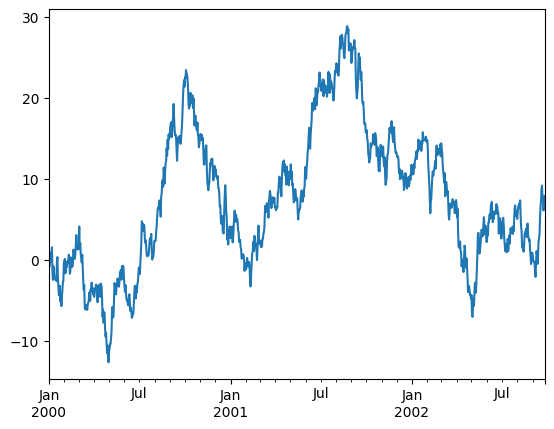

In [48]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000))
print(ts.head())
ts.cumsum().plot()

0   -2.347704
1   -1.270185
2   -0.390041
3    0.695791
4    0.824982
dtype: float64


<Axes: >

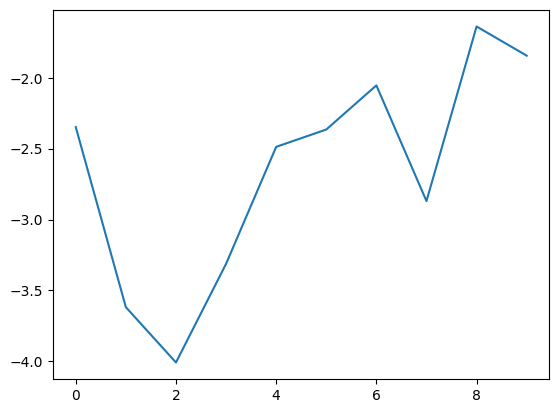

In [49]:
ts = pd.Series(np.random.randn(10), index= range(10))
print(ts.head())
ts.cumsum().plot()

<Figure size 640x480 with 0 Axes>

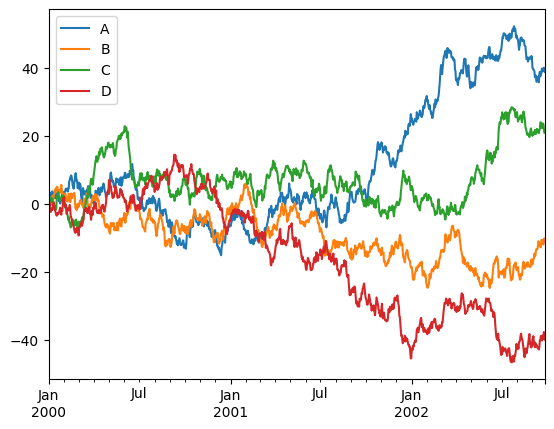

In [51]:
import matplotlib.pyplot as plt

pdf=pd.DataFrame(np.random.randn(1000, 4), index=ts.index,columns=['A', 'B', 'C', 'D'])
pdf = pdf.cumsum()
plt.figure(); pdf.plot(); plt.legend(loc='best')